> ⚠️ **Superseded (2026-06-10).** The statistics below are computed over *whole wells* and are dominated by the pre-PS descent section. The conclusions do **not** hold in the scored (post-PS) region — see [`03-eda-post-ps.ipynb`](03-eda-post-ps.ipynb) for corrected measurements and [`../modeling/01-baselines.ipynb`](../modeling/01-baselines.ipynb) for the outcome (geometry baselines refuted: RMSE 107/73 vs flat 15.9).

# ROGII — Geometry & Increment EDA (hypothesis exploration)

**Purely descriptive.** No baselines, no CV, no fitting, no prediction — those move to the submission notebook.

Question: *how much of `TVT` (depth in the rock stack) is tracked by the geometry we already know — `Z`, the
depth below sea level — and does the local change in `GR` relate to the change in `TVT` at all?*

`Z` is given everywhere, including the part we predict. If `TVT ≈ −Z + offset`, most of `TVT` is already in hand
and only the leftover (the structural/dip term) needs work. We name that leftover

```
D = TVT + Z      # structural residual; constant if TVT were exactly -Z + const
```

*Reading guide: red line on each histogram = median (value labelled); the key-metrics table states every number
with a plain meaning. True `TVT` is used for analysis only, never as a predictor.*

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.edgecolor": "#888",
})
BAR, MED, ID = "#4C78A8", "#E45756", "#54A24B"

def show_metrics(title, rows):
    df = pd.DataFrame(rows, columns=["Measurement", "Value", "What it means"])
    sty = (df.style.hide(axis="index").set_caption(title)
           .set_properties(**{"text-align": "left", "font-size": "12px", "padding": "4px 12px"})
           .set_table_styles([
               {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                                  ("text-align", "left"), ("padding", "6px 0")]},
               {"selector": "th", "props": [("text-align", "left"), ("background", "#eef1f6"),
                                            ("padding", "4px 12px")]}]))
    display(sty)

def hist_med(ax, data, title, xlabel, fmt=lambda v: f"{v:.2f}", bins=30, xlim=None):
    d = pd.Series(data).dropna()
    ax.hist(d, bins=bins, color=BAR, edgecolor="white", linewidth=0.3)
    med = d.median(); ax.axvline(med, color=MED, lw=2)
    ax.text(0.04, 0.95, f"median {fmt(med)}", transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(boxstyle="round", fc="white", ec=MED, alpha=0.9))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("wells")
    if xlim: ax.set_xlim(*xlim)

def find_data_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "data" / "raw" / "train").is_dir():
            return (c / "data" / "raw").resolve()
    raise FileNotFoundError("data root not found")

DATA = find_data_root(); TRAIN = DATA / "train"
def wid(p): return Path(p).name.split("__")[0]
def load_well(p): return pd.read_csv(p, usecols=["MD", "X", "Y", "Z", "GR", "TVT", "TVT_input"])
def corr(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[m], b[m])[0, 1] if m.sum() > 3 else np.nan

train_h = sorted(TRAIN.glob("*__horizontal_well.csv"))
rng = np.random.default_rng(0)
samp = [train_h[k] for k in rng.choice(len(train_h), 120, replace=False)]
print("sample wells:", len(samp))

sample wells: 120


## 2. Does `TVT` track `−Z`?

If geometry alone carried `TVT`, then `TVT` and `−Z` would move together and the residual `D = TVT + Z` would be
small. Per well we measure `corr(TVT, −Z)` and how large `D`'s range is vs `TVT`'s.

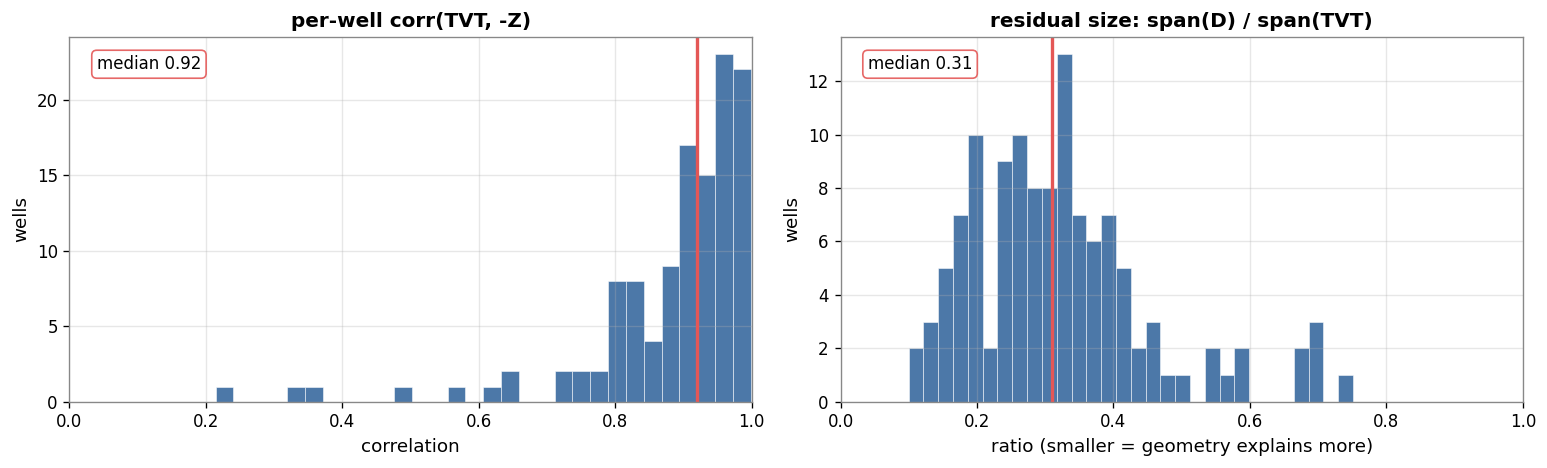

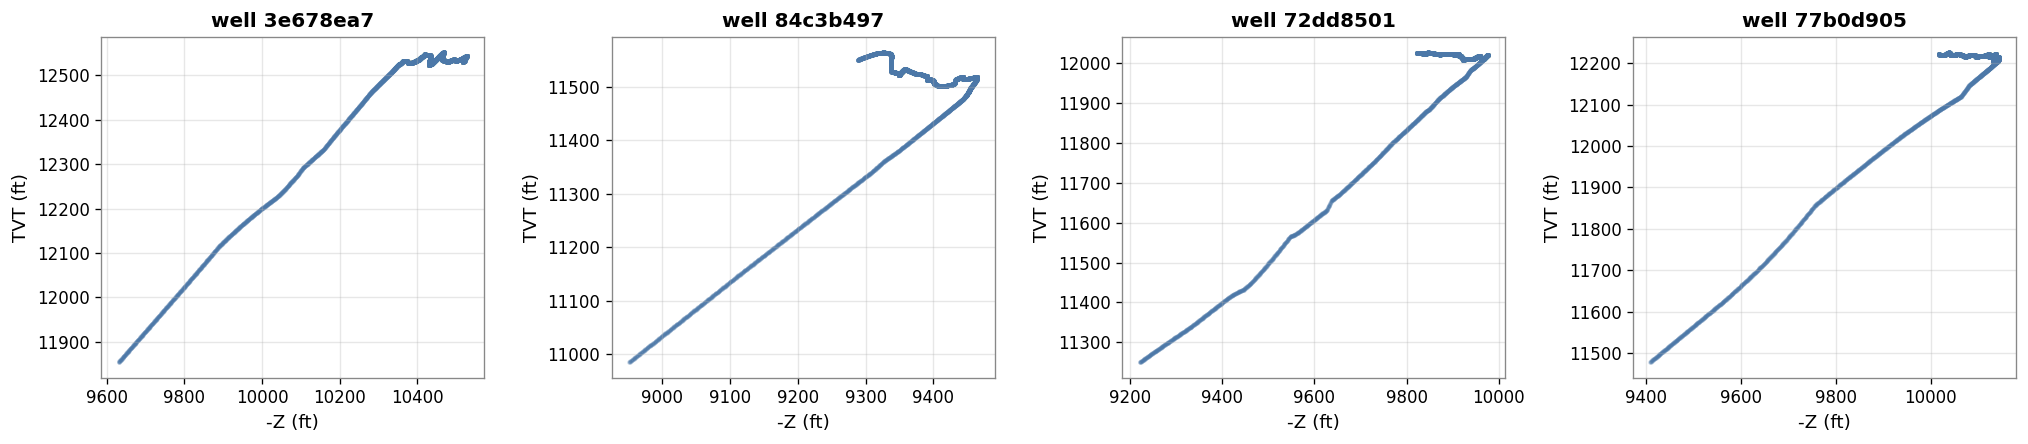

In [2]:
cor_tz, span_ratio = [], []
for p in samp:
    h = load_well(p); t, z = h.TVT.values, h.Z.values
    cor_tz.append(corr(t, -z))
    D = t + z; tspan = np.nanmax(t) - np.nanmin(t)
    span_ratio.append((np.nanmax(D) - np.nanmin(D)) / tspan if tspan else np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_med(ax[0], cor_tz, "per-well corr(TVT, -Z)", "correlation", lambda v: f"{v:.2f}", xlim=(0, 1))
hist_med(ax[1], span_ratio, "residual size: span(D) / span(TVT)", "ratio (smaller = geometry explains more)",
         lambda v: f"{v:.2f}", xlim=(0, 1))
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, p in zip(ax, samp[:4]):
    h = load_well(p)
    a.scatter(-h.Z, h.TVT, s=3, alpha=0.3, color=BAR)
    a.set_title(f"well {wid(p)}"); a.set_xlabel("-Z (ft)"); a.set_ylabel("TVT (ft)")
plt.tight_layout(); plt.show()

## 3. Does the *change* in `TVT` follow the *change* in `Z`?

The increment view (the heart of the derivative idea). Over a 25-ft step we compute `ΔTVT` and `−ΔZ`. If
`TVT ≈ −Z + offset`, then `ΔTVT ≈ −ΔZ` — points fall on the diagonal in the density plot.

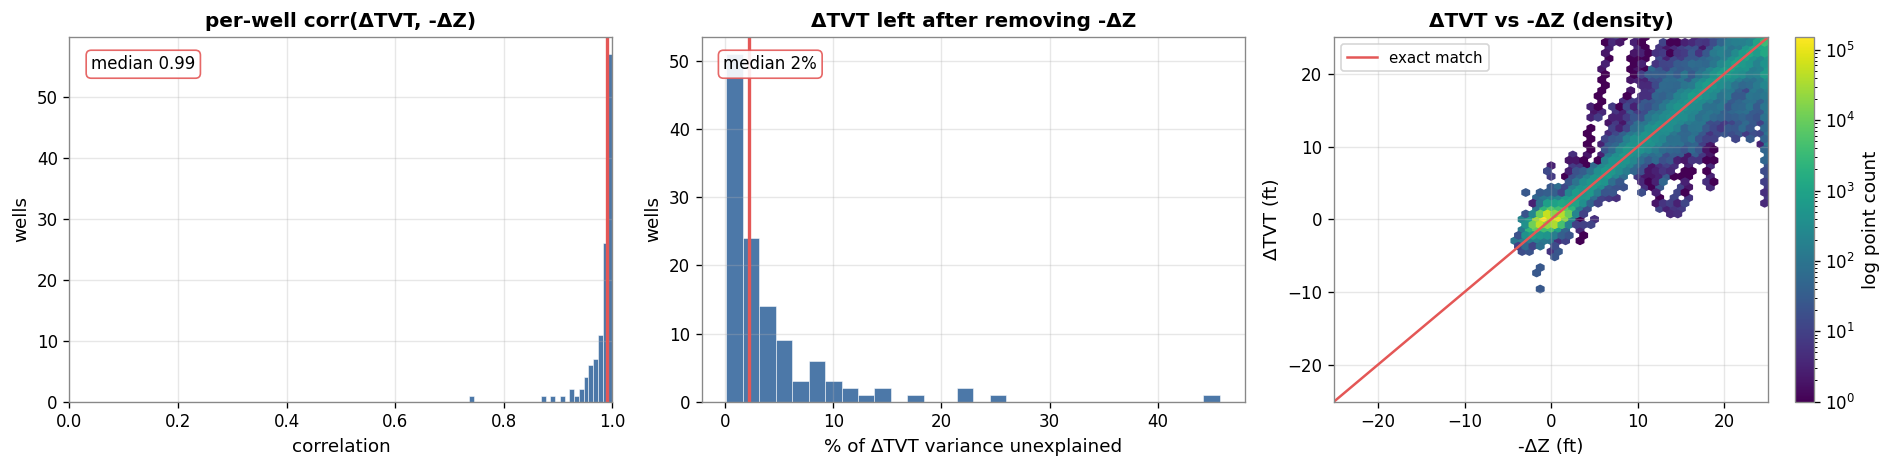

In [3]:
L = 25
cor_dd, resid_frac, dt_pool, ndz_pool = [], [], [], []
for p in samp:
    h = load_well(p); t, z = h.TVT.values, h.Z.values
    dt = t[L:] - t[:-L]; ndz = -(z[L:] - z[:-L])
    cor_dd.append(corr(dt, ndz))
    m = np.isfinite(dt) & np.isfinite(ndz)
    resid_frac.append(np.nanvar(dt[m] - ndz[m]) / np.nanvar(dt[m]) if m.sum() > 3 else np.nan)
    dt_pool.append(dt[m]); ndz_pool.append(ndz[m])
dt_pool = np.concatenate(dt_pool); ndz_pool = np.concatenate(ndz_pool)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hist_med(ax[0], cor_dd, "per-well corr(ΔTVT, -ΔZ)", "correlation", lambda v: f"{v:.2f}", xlim=(0, 1))
hist_med(ax[1], np.array(resid_frac) * 100, "ΔTVT left after removing -ΔZ", "% of ΔTVT variance unexplained",
         lambda v: f"{v:.0f}%")
lim = np.nanpercentile(np.abs(np.concatenate([ndz_pool, dt_pool])), 99)
hb = ax[2].hexbin(ndz_pool, dt_pool, gridsize=60, bins="log", cmap="viridis",
                  extent=(-lim, lim, -lim, lim))
ax[2].plot([-lim, lim], [-lim, lim], color=MED, lw=1.5, label="exact match")
ax[2].set_xlim(-lim, lim); ax[2].set_ylim(-lim, lim)
ax[2].set_xlabel("-ΔZ (ft)"); ax[2].set_ylabel("ΔTVT (ft)"); ax[2].set_title("ΔTVT vs -ΔZ (density)")
ax[2].legend(fontsize=9, loc="upper left"); fig.colorbar(hb, ax=ax[2], label="log point count")
plt.tight_layout(); plt.show()

## 4. Is the leftover `D = TVT + Z` smooth, and does its pre-PS trend continue?

For the residual idea to help, `D` should be slowly varying and behave similarly before and after PS. We plot `D`
along the well (PS dashed), compare `D`'s roughness to `TVT`'s, and compare each well's pre-PS vs post-PS `D`
slope (points near the diagonal = trend continues).

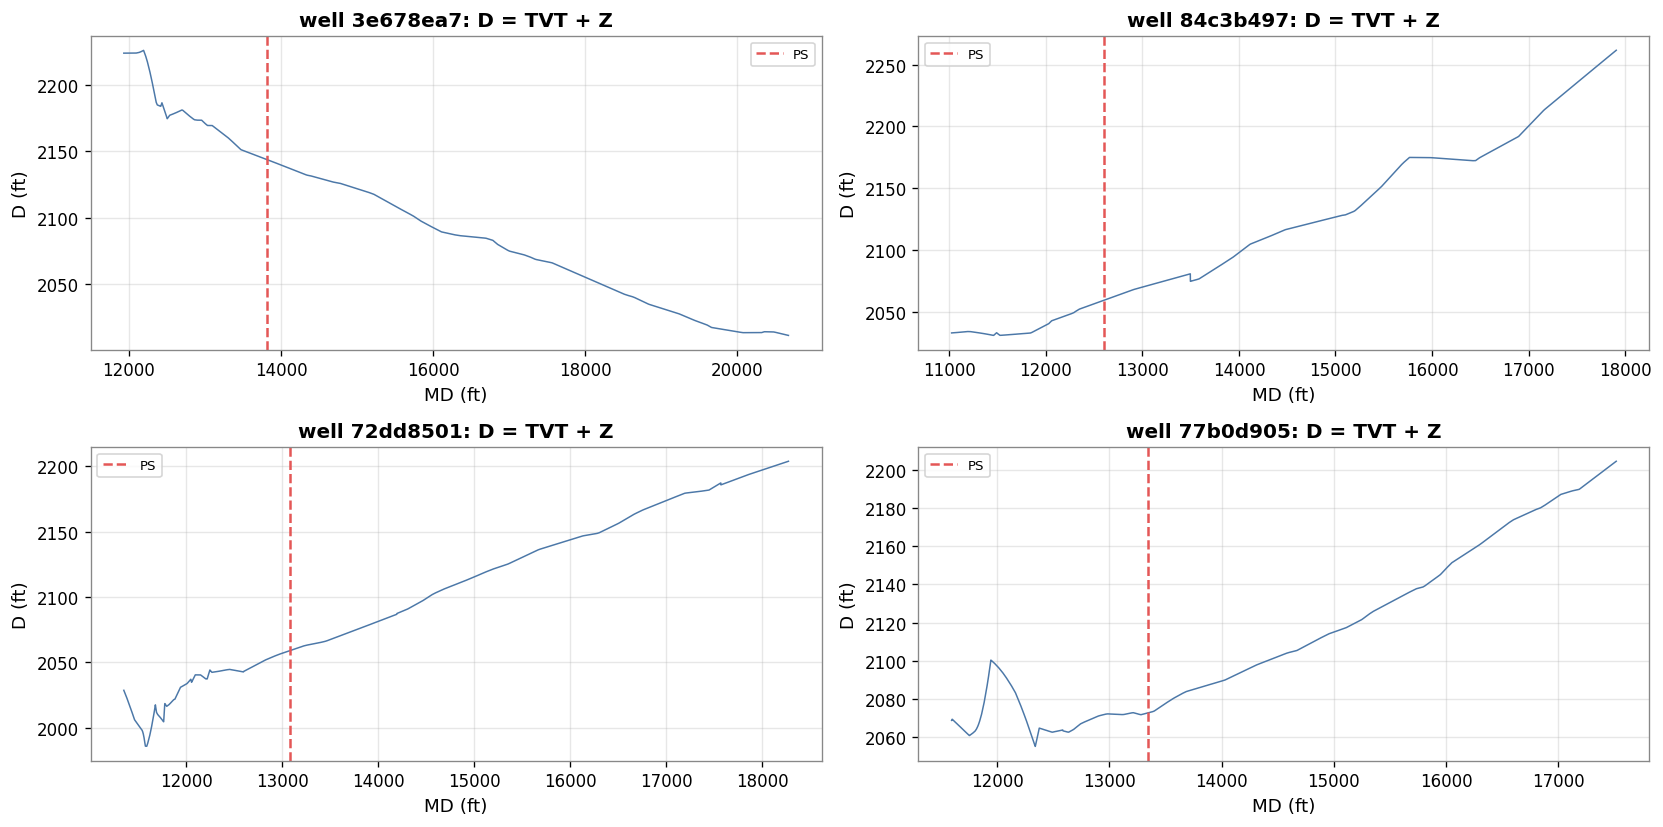

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
for a, p in zip(ax.ravel(), samp[:4]):
    h = load_well(p); D = (h.TVT + h.Z).values
    ps = int(h["TVT_input"].isna().values.argmax())
    a.plot(h.MD, D, lw=0.9, color=BAR)
    a.axvline(h.MD.iloc[ps], color=MED, ls="--", lw=1.5, label="PS")
    a.set_title(f"well {wid(p)}: D = TVT + Z"); a.set_xlabel("MD (ft)"); a.set_ylabel("D (ft)")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

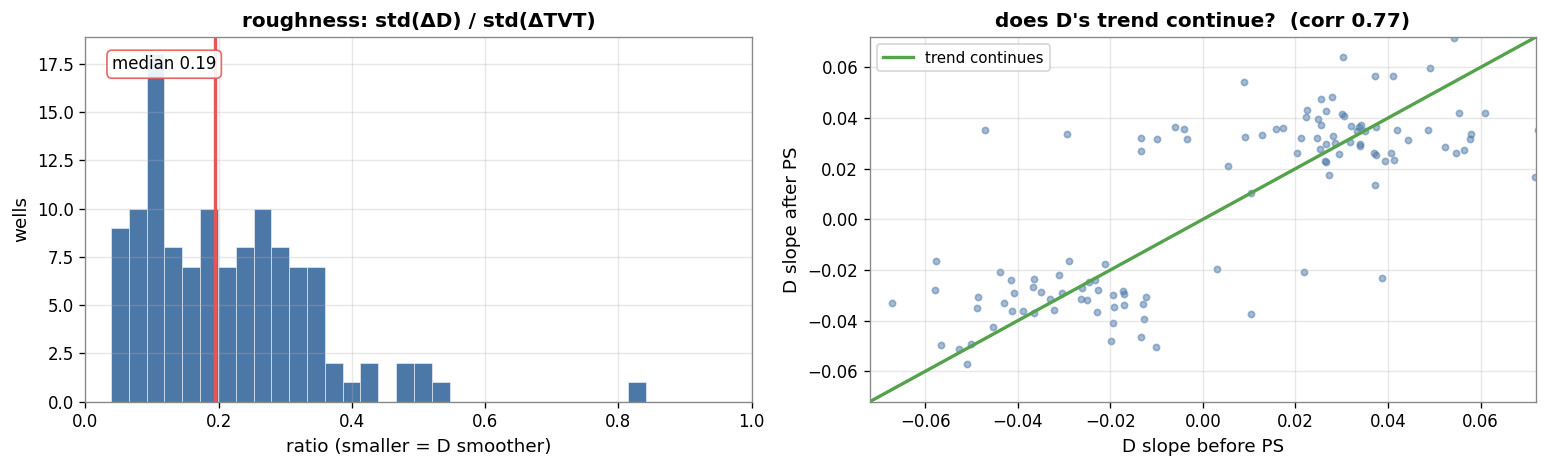

In [5]:
rough_ratio, slope_pre, slope_post = [], [], []
def slope(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return np.polyfit(x[m], y[m], 1)[0] if m.sum() > 5 else np.nan
for p in samp:
    h = load_well(p); t, z = h.TVT.values, h.Z.values; D = t + z; md_ = h.MD.values
    ps = int(h["TVT_input"].isna().values.argmax())
    rough_ratio.append(np.nanstd(np.diff(D)) / np.nanstd(np.diff(t)))
    slope_pre.append(slope(md_[:ps], D[:ps])); slope_post.append(slope(md_[ps:], D[ps:]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_med(ax[0], rough_ratio, "roughness: std(ΔD) / std(ΔTVT)", "ratio (smaller = D smoother)",
         lambda v: f"{v:.2f}", xlim=(0, 1))
ax[1].scatter(slope_pre, slope_post, s=14, alpha=0.5, color=BAR)
lim = np.nanpercentile(np.abs(slope_pre + slope_post), 98)
ax[1].plot([-lim, lim], [-lim, lim], color=ID, lw=2, label="trend continues")
ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim)
ax[1].set_xlabel("D slope before PS"); ax[1].set_ylabel("D slope after PS")
ax[1].set_title(f"does D's trend continue?  (corr {corr(np.array(slope_pre), np.array(slope_post)):.2f})")
ax[1].legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

## 5. Does local `GR` change relate to `TVT` change?

If local `ΔGR` predicted `ΔTVT`, a simple derivative model on `GR` would work. We measure per-well
`corr(ΔGR, ΔTVT)` and within-well `corr(GR, TVT)`. Weak values mean `GR` carries little point-to-point — it only
becomes useful as a *pattern* matched against the typewell.

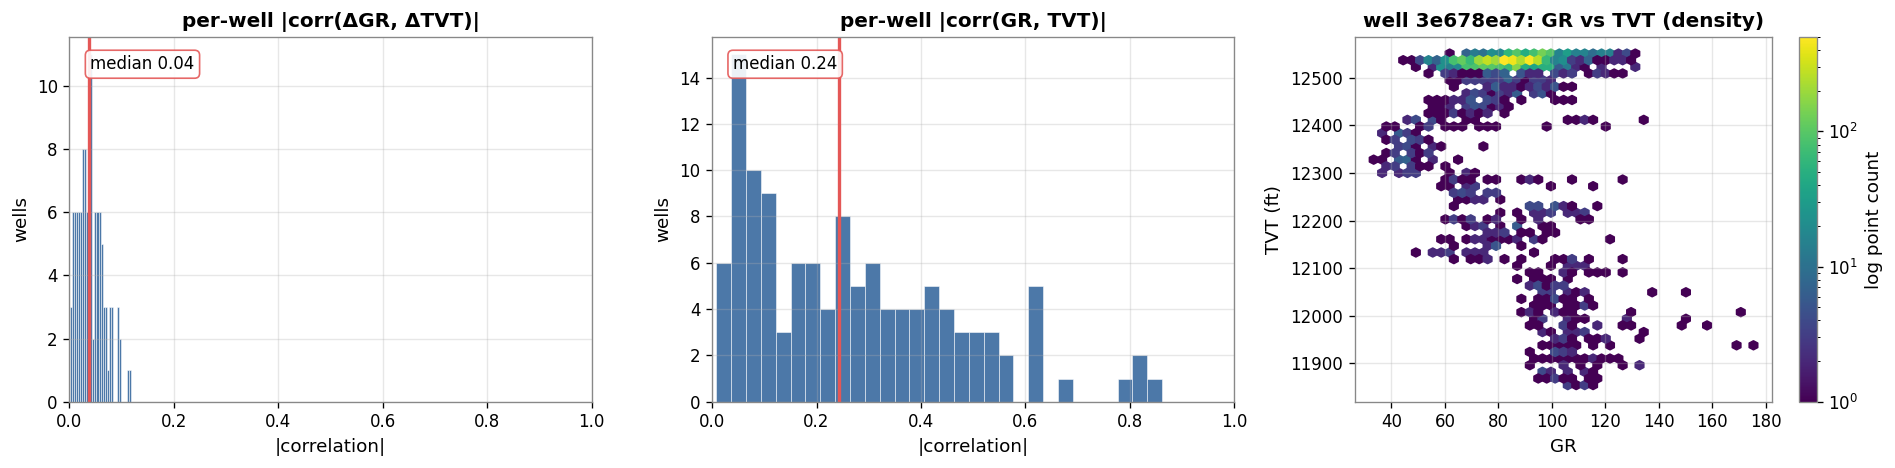

In [6]:
cor_dgr_dtvt, cor_gr_tvt = [], []
for p in samp:
    h = load_well(p); t, g = h.TVT.values, h.GR.values
    cor_dgr_dtvt.append(corr(g[L:] - g[:-L], t[L:] - t[:-L]))
    cor_gr_tvt.append(corr(g, t))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hist_med(ax[0], np.abs(cor_dgr_dtvt), "per-well |corr(ΔGR, ΔTVT)|", "|correlation|", lambda v: f"{v:.2f}", xlim=(0, 1))
hist_med(ax[1], np.abs(cor_gr_tvt), "per-well |corr(GR, TVT)|", "|correlation|", lambda v: f"{v:.2f}", xlim=(0, 1))
h = load_well(samp[0])
hb = ax[2].hexbin(h.GR, h.TVT, gridsize=45, bins="log", cmap="viridis")
ax[2].set_title(f"well {wid(samp[0])}: GR vs TVT (density)"); ax[2].set_xlabel("GR"); ax[2].set_ylabel("TVT (ft)")
fig.colorbar(hb, ax=ax[2], label="log point count")
plt.tight_layout(); plt.show()

## 6. Key metrics

In [7]:
show_metrics("Geometry & increment EDA — key metrics", [
    ["TVT vs -Z (correlation)", f"{np.nanmedian(cor_tz):.2f}", "TVT closely follows -Z"],
    ["residual size span(D)/span(TVT)", f"{np.nanmedian(span_ratio):.2f}",
     "geometry removes ~70% of TVT's range; ~230 ft left"],
    ["ΔTVT vs -ΔZ (correlation)", f"{np.nanmedian(cor_dd):.2f}", "local change in TVT ≈ change in -Z"],
    ["ΔTVT left after -ΔZ", f"{np.nanmedian(resid_frac)*100:.0f}%", "geometry explains ~98% of local motion"],
    ["D smoothness std(ΔD)/std(ΔTVT)", f"{np.nanmedian(rough_ratio):.2f}", "the residual D is ~5x smoother than TVT"],
    ["D trend pre vs post PS (corr)", f"{corr(np.array(slope_pre), np.array(slope_post)):.2f}",
     "dip trend mostly continues past PS"],
    ["ΔGR vs ΔTVT (|correlation|)", f"{np.nanmedian(np.abs(cor_dgr_dtvt)):.2f}", "local GR change carries ~no signal"],
    ["GR vs TVT (|correlation|)", f"{np.nanmedian(np.abs(cor_gr_tvt)):.2f}", "GR weakly related to depth point-wise"],
])

Measurement,Value,What it means
TVT vs -Z (correlation),0.92,TVT closely follows -Z
residual size span(D)/span(TVT),0.31,geometry removes ~70% of TVT's range; ~230 ft left
ΔTVT vs -ΔZ (correlation),0.99,local change in TVT ≈ change in -Z
ΔTVT left after -ΔZ,2%,geometry explains ~98% of local motion
D smoothness std(ΔD)/std(ΔTVT),0.19,the residual D is ~5x smoother than TVT
D trend pre vs post PS (corr),0.77,dip trend mostly continues past PS
ΔGR vs ΔTVT (|correlation|),0.04,local GR change carries ~no signal
GR vs TVT (|correlation|),0.24,GR weakly related to depth point-wise


## Findings & analysis

**Facts (measured, 120-well sample)**
- `TVT` vs `−Z`: median correlation 0.92.
- Structural residual `D = TVT + Z` spans ~31% of `TVT`'s span (median) → about ~230 ft on a typical well.
- At a 25-ft step, `ΔTVT` vs `−ΔZ`: median correlation 0.99; only ~2% of `ΔTVT` variance is left after subtracting `−ΔZ`.
- `D` is smooth: its step-to-step change is ~19% of `TVT`'s.
- `D`'s slope before PS vs after PS: correlation 0.77.
- Local `GR` change vs `TVT` change: median |corr| 0.04. `GR` vs `TVT` within a well: median |corr| 0.24.

**Analysis**
- The fast/local part of `TVT` is almost entirely `−Z` (98% of step variance). Predicting the *change* in `TVT` from the change in `Z` is near-exact — the derivative instinct holds.
- But absolute `TVT = −Z + D`, and `D` still varies ~230 ft within a well. That residual — not the `−Z` part — is where the error budget lives.
- `D` is smooth and its trend is moderately persistent past PS (0.77), so extrapolating `D` from the known pre-PS segment should capture much of it cheaply.
- Local `GR` is near-useless for `TVT` change (0.04). `GR` is not a derivative signal; its value can only come from matching the `GR` *pattern* against the typewell to pin `D`'s absolute level — i.e. sequence alignment, not point-wise deltas.
- Reframing: the real prediction target is `D` (smooth, ~230 ft range). Geometry gives `−Z` for free; the pre-PS trend extends `D`; `GR`–typewell alignment is what corrects `D`'s drift far from PS.